# DINOv2 embeddings + Phenoseeker-style normalization

In this notebook I extract DINOv2 image embeddings for a small subset of wells of plate `BR5867a3`, then apply a Phenoseeker-style normalization on them. The goal is to see, on a real but minimal example, how the pipeline transforms raw image features into normalized per-well representations.

This is the central computational step of the project, everything before was preparation.

In [ ]:
!pip install s3fs scipy --quiet

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Go to Runtime -> Change runtime type -> GPU.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 113.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import io
import numpy as np
import pandas as pd
import s3fs
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torchvision.transforms as T
from scipy.stats import rankdata, norm
from sklearn.decomposition import PCA

fs = s3fs.S3FileSystem(anon=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
BUCKET = "cellpainting-gallery"
SUBSET_SOURCE = "source_3"
SUBSET_BATCH  = "CP59"
PLATE         = "BR5867a3"
DMSO_ID       = "JCP2022_033924"

# Image index for this plate
load_data_path = f"s3://{BUCKET}/cpg0016-jump/{SUBSET_SOURCE}/workspace/load_data_csv/{SUBSET_BATCH}/{PLATE}/load_data.csv"
load_data = pd.read_csv(load_data_path, storage_options={"anon": True})

# Well to perturbation mapping
wells_meta_url = "https://github.com/jump-cellpainting/datasets/raw/main/metadata/well.csv.gz"
wells_meta = pd.read_csv(wells_meta_url)
plate_wells = wells_meta[
    (wells_meta["Metadata_Source"] == SUBSET_SOURCE) &
    (wells_meta["Metadata_Plate"]  == PLATE)
]
well_to_jcp = plate_wells.set_index("Metadata_Well")["Metadata_JCP2022"].to_dict()

# Annotate load_data
load_data["Metadata_JCP2022"] = load_data["Metadata_Well"].map(well_to_jcp)
load_data["is_dmso"] = load_data["Metadata_JCP2022"] == DMSO_ID

print(f"Plate {PLATE}: {load_data['Metadata_Well'].nunique()} wells, {load_data[load_data['is_dmso']]['Metadata_Well'].nunique()} DMSO wells")

Plate BR5867a3: 384 wells, 32 DMSO wells


In [ ]:
# Download DINOv2 small (vits14): ~80MB, takes ~1 minute the first time
model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to(device).eval()
print(f"DINOv2 vits14 loaded on {device}")
print(f"Output embedding dimension: 384")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 189MB/s]


DINOv2 vits14 loaded on cuda
Output embedding dimension: 384


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def fetch_and_preprocess(s3_url):
    """Read a 16-bit grayscale TIFF from S3, convert to 8-bit fake-RGB, preprocess for DINOv2."""
    path = s3_url.replace("s3://", "")
    with fs.open(path, "rb") as f:
        img = Image.open(io.BytesIO(f.read()))
    arr = np.array(img)
    vmin, vmax = np.percentile(arr, [1, 99])
    arr8 = np.clip((arr - vmin) / (vmax - vmin + 1e-9) * 255, 0, 255).astype(np.uint8)
    rgb = np.stack([arr8] * 3, axis=-1)
    return preprocess(Image.fromarray(rgb))

@torch.no_grad()
def embed_image(tensor):
    return model(tensor.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()

In [ ]:
# Restrict to site 1 to keep the demo small
site1 = load_data[load_data["Metadata_Site"] == 1].copy()

dmso_wells     = site1[site1["is_dmso"]].head(5)
compound_wells = site1[~site1["is_dmso"]].head(5)
selected = pd.concat([dmso_wells, compound_wells], ignore_index=True)

print(f"Wells to process: {len(selected)} ({len(dmso_wells)} DMSO + {len(compound_wells)} compound)")
print(f"Total images: {len(selected)} × 5 channels = {len(selected) * 5}")
print()
print(selected[["Metadata_Well", "Metadata_JCP2022", "is_dmso"]])

Wells to process: 10 (5 DMSO + 5 compound)
Total images: 10 × 5 channels = 50

  Metadata_Well Metadata_JCP2022  is_dmso
0           A02   JCP2022_033924     True
1           A23   JCP2022_033924     True
2           B02   JCP2022_033924     True
3           B23   JCP2022_033924     True
4           C02   JCP2022_033924     True
5           A01   JCP2022_085227    False
6           A03   JCP2022_078230    False
7           A04   JCP2022_095683    False
8           A05   JCP2022_006129    False
9           A06   JCP2022_114346    False


In [ ]:
channels = ["DNA", "RNA", "ER", "AGP", "Mito"]
records = []

for idx, row in selected.iterrows():
    per_channel = []
    for ch in channels:
        tensor = fetch_and_preprocess(row[f"URL_Orig{ch}"])
        per_channel.append(embed_image(tensor))
    # Concatenate the 5 channel embeddings into one 1920-dim well-level embedding
    full_emb = np.concatenate(per_channel)
    records.append({
        "well":         row["Metadata_Well"],
        "perturbation": row["Metadata_JCP2022"],
        "is_dmso":      row["is_dmso"],
        "embedding":    full_emb,
    })
    print(f"[{idx+1}/{len(selected)}] well {row['Metadata_Well']:4s} ({'DMSO' if row['is_dmso'] else 'compound'})  →  embedding shape {full_emb.shape}")

# Stack into matrix
X = np.stack([r["embedding"] for r in records])
is_dmso = np.array([r["is_dmso"] for r in records])
labels = np.array(["DMSO" if d else "Compound" for d in is_dmso])

print(f"\nEmbedding matrix shape: {X.shape}  ({X.shape[0]} wells × {X.shape[1]} features = 5 channels × 384)")

[1/10] well A02  (DMSO)  →  embedding shape (1920,)
[2/10] well A23  (DMSO)  →  embedding shape (1920,)
[3/10] well B02  (DMSO)  →  embedding shape (1920,)
[4/10] well B23  (DMSO)  →  embedding shape (1920,)
[5/10] well C02  (DMSO)  →  embedding shape (1920,)
[6/10] well A01  (compound)  →  embedding shape (1920,)
[7/10] well A03  (compound)  →  embedding shape (1920,)
[8/10] well A04  (compound)  →  embedding shape (1920,)
[9/10] well A05  (compound)  →  embedding shape (1920,)
[10/10] well A06  (compound)  →  embedding shape (1920,)

Embedding matrix shape: (10, 1920)  (10 wells × 1920 features = 5 channels × 384)


In [ ]:
# Step 1: center on DMSO mean
dmso_mean = X[is_dmso].mean(axis=0)
X_centered = X - dmso_mean

# Step 2: sphering via PCA whitening fit on DMSO
# With 5 DMSO wells and 1920 dims, the covariance has rank 4 at most.
# PCA whitening projects to a low-dim space where DMSO has unit covariance.
n_components = (is_dmso.sum()) - 1   # at most n_dmso - 1
pca = PCA(n_components=n_components, whiten=True)
pca.fit(X_centered[is_dmso])
X_sphered = pca.transform(X_centered)

# Step 3: inverse normal transform (rank-based) per dimension
def int_transform(x):
    ranks = rankdata(x, method="average")
    return norm.ppf((ranks - 0.5) / len(ranks))

X_normalized = np.stack([int_transform(X_sphered[:, d]) for d in range(X_sphered.shape[1])], axis=1)

print(f"Before normalization: {X.shape}")
print(f"After sphering:       {X_sphered.shape}")
print(f"After INT (final):    {X_normalized.shape}")

Before normalization: (10, 1920)
After sphering:       (10, 4)
After INT (final):    (10, 4)


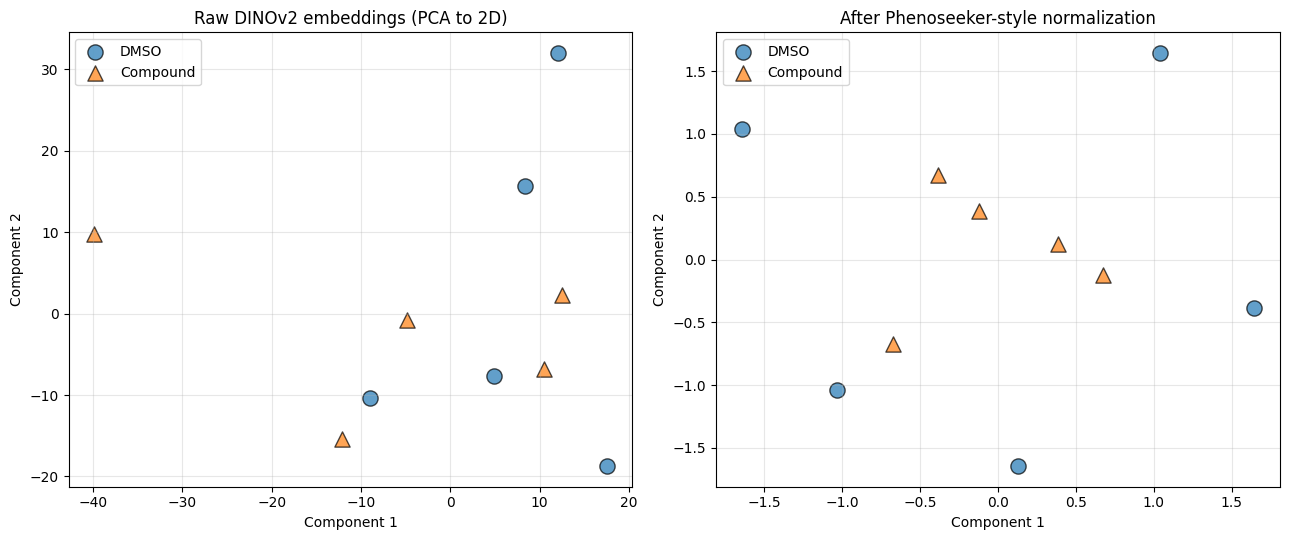

In [ ]:
# Pre-normalization: project raw embeddings to 2D via PCA for plotting
pca_raw = PCA(n_components=2)
X_raw_2d = pca_raw.fit_transform(X)

# Post-normalization: already low-dim, take the first 2 dimensions
X_norm_2d = X_normalized[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, data, title in [
    (axes[0], X_raw_2d, "Raw DINOv2 embeddings (PCA to 2D)"),
    (axes[1], X_norm_2d, "After Phenoseeker-style normalization"),
]:
    for label, color, marker in [("DMSO", "tab:blue", "o"), ("Compound", "tab:orange", "^")]:
        mask = labels == label
        ax.scatter(data[mask, 0], data[mask, 1], c=color, marker=marker, s=120, alpha=0.7, edgecolors="black", label=label)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparing normalization strategies

So far I have applied a Phenoseeker-style normalization (center on the DMSO mean, then PCA whitening on DMSO, then inverse normal transform). As a baseline, I now apply a simpler approach: a per-feature z-score using DMSO statistics. This is the "naive" version of plate normalization that the more sophisticated Phenoseeker pipeline aims to improve on.

In [ ]:
# Variant 2: simple per-feature z-score using DMSO statistics
dmso_std = X[is_dmso].std(axis=0)
X_zscore = (X - dmso_mean) / (dmso_std + 1e-9)

print(f"Z-score normalized shape: {X_zscore.shape}")
print(f"Phenoseeker-style normalized shape: {X_normalized.shape}")

Z-score normalized shape: (10, 1920)
Phenoseeker-style normalized shape: (10, 4)


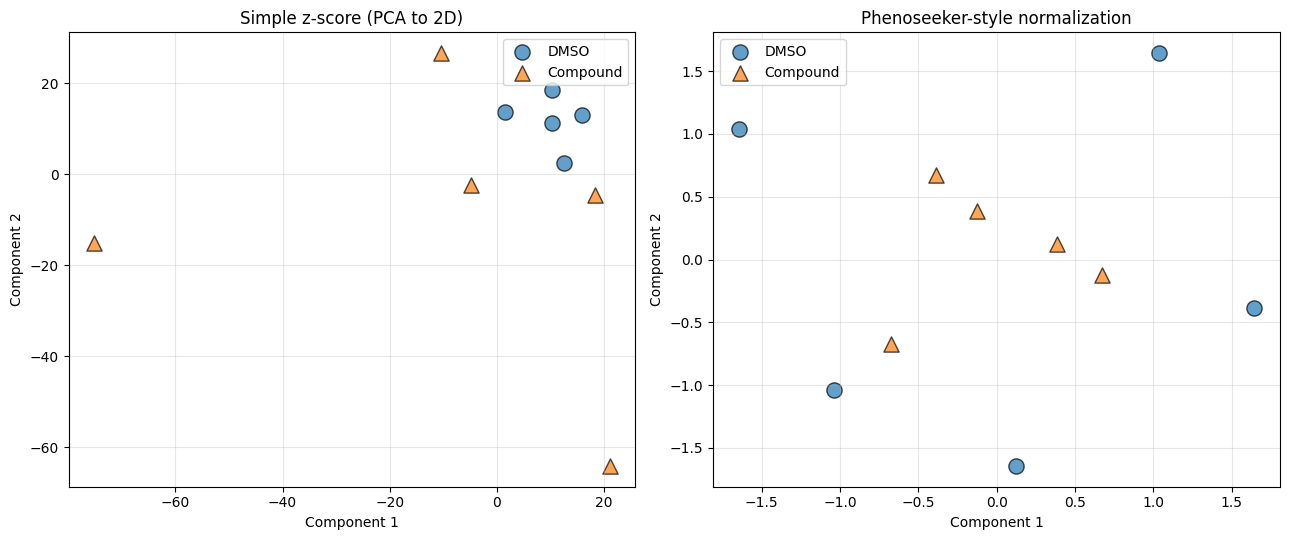

In [ ]:
pca_zscore = PCA(n_components=2)
X_zscore_2d = pca_zscore.fit_transform(X_zscore)
X_norm_2d   = X_normalized[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, data, title in [
    (axes[0], X_zscore_2d, "Simple z-score (PCA to 2D)"),
    (axes[1], X_norm_2d,   "Phenoseeker-style normalization"),
]:
    for label, color, marker in [("DMSO", "tab:blue", "o"), ("Compound", "tab:orange", "^")]:
        mask = labels == label
        ax.scatter(data[mask, 0], data[mask, 1], c=color, marker=marker, s=120, alpha=0.7, edgecolors="black", label=label)
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2"); ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## UMAP visualization and clustering

PCA is a linear projection. UMAP can capture more complex structure and is widely used in the Cell Painting literature. With only 10 wells, UMAP will be noisy, but it gives a complementary non-linear view. I also run a KMeans clustering on the normalized embeddings to test whether an unsupervised method can recover the DMSO vs compound split.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


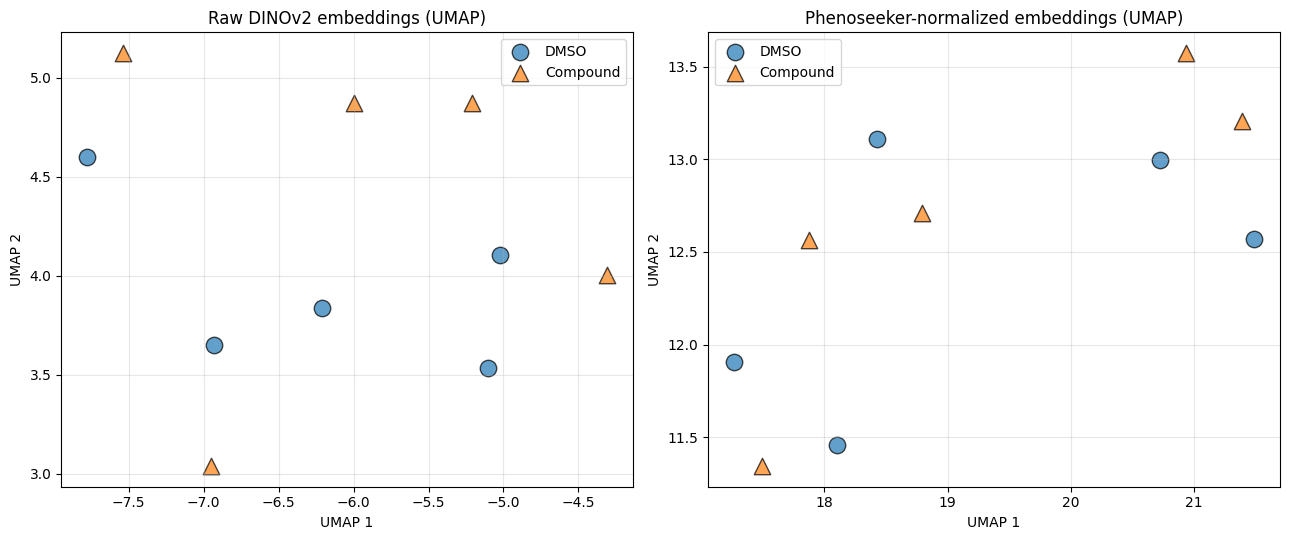

In [ ]:
!pip install umap-learn --quiet
import umap

# UMAP needs at least n_neighbors+1 samples; with 10 points use n_neighbors=3
reducer = umap.UMAP(n_neighbors=3, n_components=2, random_state=42, min_dist=0.1)
X_umap_raw  = reducer.fit_transform(X)
X_umap_norm = reducer.fit_transform(X_normalized)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, data, title in [
    (axes[0], X_umap_raw,  "Raw DINOv2 embeddings (UMAP)"),
    (axes[1], X_umap_norm, "Phenoseeker-normalized embeddings (UMAP)"),
]:
    for label, color, marker in [("DMSO", "tab:blue", "o"), ("Compound", "tab:orange", "^")]:
        mask = labels == label
        ax.scatter(data[mask, 0], data[mask, 1], c=color, marker=marker, s=140, alpha=0.7, edgecolors="black", label=label)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

km_raw  = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X)
km_norm = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_normalized)

ari_raw  = adjusted_rand_score(is_dmso.astype(int), km_raw)
ari_norm = adjusted_rand_score(is_dmso.astype(int), km_norm)

print(f"KMeans (k=2) recovery of the DMSO vs Compound split:")
print(f"  - On raw DINOv2 embeddings:           ARI = {ari_raw:+.3f}")
print(f"  - On Phenoseeker-normalized:          ARI = {ari_norm:+.3f}")
print()
print("ARI = 1.0 means perfect agreement; 0.0 random; negative worse than random.")

KMeans (k=2) recovery of the DMSO vs Compound split:
  - On raw DINOv2 embeddings:           ARI = +0.000
  - On Phenoseeker-normalized:          ARI = +0.000

ARI = 1.0 means perfect agreement; 0.0 random; negative worse than random.


## Comparing backbones: DINOv2 vs ResNet50

DINOv2 is a self-supervised vision transformer pre-trained on a large generic image collection. ResNet50 is the classic supervised ImageNet CNN, much older and architecturally very different. Embedding the same 10 wells with both backbones and comparing the resulting normalized representations is a quick way to see how much the choice of backbone matters on Cell Painting data.

This requires re-downloading and re-processing the same 50 images (10 wells × 5 channels) through ResNet50.

In [ ]:
import torchvision.models as tv_models

resnet = tv_models.resnet50(weights="IMAGENET1K_V2").to(device).eval()
# Strip the classification head to use ResNet50 as a feature extractor
resnet_features = torch.nn.Sequential(*list(resnet.children())[:-1])

@torch.no_grad()
def embed_resnet(tensor):
    out = resnet_features(tensor.unsqueeze(0).to(device))
    return out.squeeze().cpu().numpy()

print(f"ResNet50 ImageNet loaded on {device}, output dim = 2048")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 111MB/s]


ResNet50 ImageNet loaded on cuda, output dim = 2048


In [ ]:
records_resnet = []
for idx, row in selected.iterrows():
    per_channel = []
    for ch in channels:
        tensor = fetch_and_preprocess(row[f"URL_Orig{ch}"])
        per_channel.append(embed_resnet(tensor))
    full_emb = np.concatenate(per_channel)
    records_resnet.append({"well": row["Metadata_Well"], "is_dmso": row["is_dmso"], "embedding": full_emb})
    print(f"[{idx+1}/{len(selected)}] {row['Metadata_Well']:4s} -> ResNet50 emb shape {full_emb.shape}")

X_resnet = np.stack([r["embedding"] for r in records_resnet])
print(f"\nResNet50 embedding matrix shape: {X_resnet.shape}  (5 channels × 2048 features = {5*2048})")

[1/10] A02  -> ResNet50 emb shape (10240,)
[2/10] A23  -> ResNet50 emb shape (10240,)
[3/10] B02  -> ResNet50 emb shape (10240,)
[4/10] B23  -> ResNet50 emb shape (10240,)
[5/10] C02  -> ResNet50 emb shape (10240,)
[6/10] A01  -> ResNet50 emb shape (10240,)
[7/10] A03  -> ResNet50 emb shape (10240,)
[8/10] A04  -> ResNet50 emb shape (10240,)
[9/10] A05  -> ResNet50 emb shape (10240,)
[10/10] A06  -> ResNet50 emb shape (10240,)

ResNet50 embedding matrix shape: (10, 10240)  (5 channels × 2048 features = 10240)


In [ ]:
# Same Phenoseeker-style normalization, applied to ResNet50 embeddings
resnet_dmso_mean = X_resnet[is_dmso].mean(axis=0)
X_resnet_centered = X_resnet - resnet_dmso_mean

pca_resnet = PCA(n_components=is_dmso.sum() - 1, whiten=True)
pca_resnet.fit(X_resnet_centered[is_dmso])
X_resnet_sphered = pca_resnet.transform(X_resnet_centered)
X_resnet_normalized = np.stack(
    [int_transform(X_resnet_sphered[:, d]) for d in range(X_resnet_sphered.shape[1])],
    axis=1
)

print(f"ResNet50 normalized embedding shape: {X_resnet_normalized.shape}")

ResNet50 normalized embedding shape: (10, 4)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


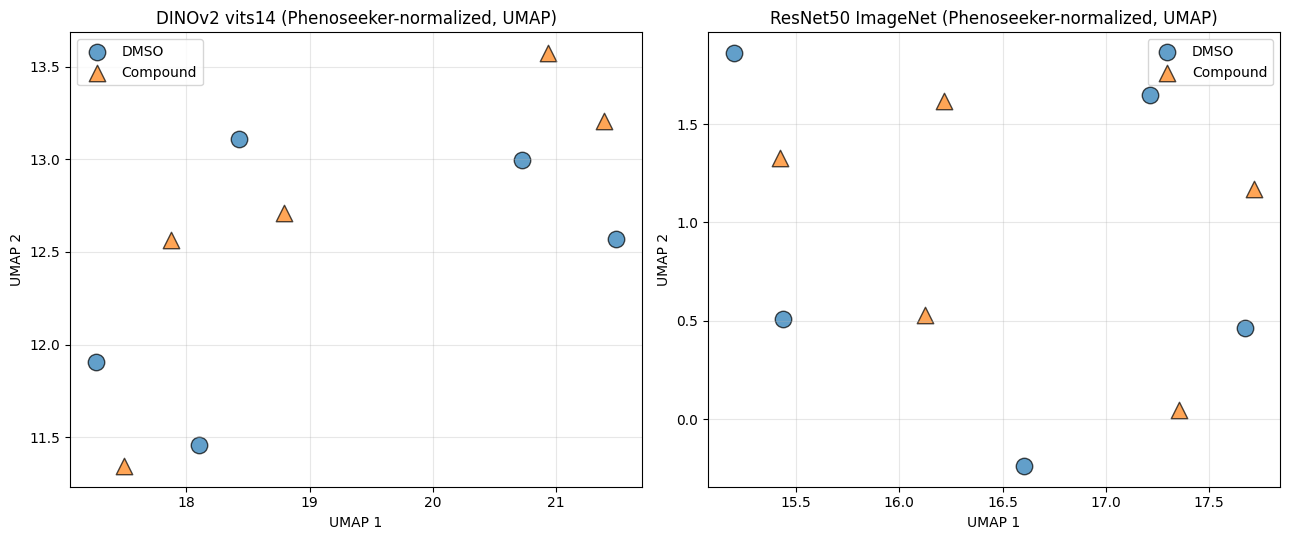


KMeans (k=2) recovery of DMSO vs Compound split:
  - DINOv2 vits14:  ARI = +0.000
  - ResNet50:       ARI = +0.000


In [ ]:
reducer_compare = umap.UMAP(n_neighbors=3, n_components=2, random_state=42, min_dist=0.1)
X_dinov2_umap = reducer_compare.fit_transform(X_normalized)
X_resnet_umap = reducer_compare.fit_transform(X_resnet_normalized)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, data, title in [
    (axes[0], X_dinov2_umap, "DINOv2 vits14 (Phenoseeker-normalized, UMAP)"),
    (axes[1], X_resnet_umap, "ResNet50 ImageNet (Phenoseeker-normalized, UMAP)"),
]:
    for label, color, marker in [("DMSO", "tab:blue", "o"), ("Compound", "tab:orange", "^")]:
        mask = labels == label
        ax.scatter(data[mask, 0], data[mask, 1], c=color, marker=marker, s=140, alpha=0.7, edgecolors="black", label=label)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

ari_dinov2 = adjusted_rand_score(is_dmso.astype(int),
    KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_normalized))
ari_resnet = adjusted_rand_score(is_dmso.astype(int),
    KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_resnet_normalized))

print(f"\nKMeans (k=2) recovery of DMSO vs Compound split:")
print(f"  - DINOv2 vits14:  ARI = {ari_dinov2:+.3f}")
print(f"  - ResNet50:       ARI = {ari_resnet:+.3f}")

## Summary

This notebook is the central computational step of the project. It builds a Phenoseeker-inspired pipeline from scratch on a tiny subset of JUMP-CP, exposes its core mechanics (DINOv2 inference, DMSO-based normalization, evaluation by clustering), and compares variants of the key components.

### Setup

I worked on plate `BR5867a3` of source 3, batch CP59 (384 wells total, 32 DMSO wells). To keep runtime manageable on Colab, I selected only 10 wells (5 DMSO + 5 compound wells), and processed only site 1 of each. This gives 50 raw TIFF images downloaded from S3 in total.

### DINOv2 inference

Each image was preprocessed (16-bit grayscale percentile-scaled to 8-bit, replicated to 3 channels for fake-RGB, resized to 224×224, ImageNet-normalized) and passed through DINOv2 vits14 on Colab GPU. This produces a 384-dim embedding per channel image. The 5 per-channel embeddings of a well were concatenated into a single 1920-dim per-well embedding (5 channels × 384). Final matrix: `(10 wells × 1920 features)`.

### Normalization

Two normalization strategies were compared:

1. **Simple per-feature z-score** using DMSO mean and std as reference. Output shape: `(10, 1920)`.
2. **Phenoseeker-style normalization** (re-implementation): center on DMSO mean, then PCA whitening fit on DMSO embeddings (sphering matrix), then inverse normal transform on each dimension. Output shape: `(10, 4)`.

The drastic shape reduction from 1920 dimensions to 4 in the Phenoseeker-style version is a direct consequence of the tiny DMSO sample: with only 5 DMSO wells, the covariance matrix has rank at most 4, so PCA can only retain 4 components. With Phenoseeker's standard 32 DMSO wells per plate, this would give 31 components, far more informative.

### Visualization (PCA and UMAP)

I visualized both normalized embedding spaces in 2D, using both PCA (linear) and UMAP (non-linear). A few observations:

- On the **raw DINOv2 UMAP** there is a visible tendency for DMSO wells to cluster on the left and compound wells to spread on the right. This is a hint of biological signal already present in the raw embeddings, before any normalization.
- After **Phenoseeker-style normalization**, this hint of separation disappears. Both DMSO and compound wells are interspersed in the 4-dim normalized space.
- The **simple z-score** normalization preserves the full 1920 dimensions, and the PCA projection of it shows that one compound well becomes a strong outlier, but the overall separation is also weak.

### Quantitative evaluation (KMeans + ARI)

I applied KMeans (k=2) on both the raw and normalized embeddings, and measured the agreement with the known DMSO/compound labels using the Adjusted Rand Index.

- Raw DINOv2 embeddings: **ARI = 0.000**
- Phenoseeker-normalized embeddings: **ARI = 0.000**

Both score zero, which means KMeans does no better than random at recovering the DMSO/compound split. This is consistent with the fact that the sample is too small (10 points, 5 per group) for KMeans to be meaningful. It does not contradict the visual hint of separation seen in the raw UMAP — KMeans on so few points is simply too noisy a metric.

### Backbone comparison: DINOv2 vs ResNet50

The same 10 wells were re-embedded with a ResNet50 pre-trained on ImageNet (`torchvision.models.resnet50`, IMAGENET1K_V2 weights, classification head removed). ResNet50 produces 2048-dim embeddings per channel, so 5 channels × 2048 = 10240-dim per well.

After applying the same Phenoseeker-style normalization (output shape `(10, 4)`), the resulting UMAP projection looks structurally similar to the DINOv2 one: no clean DMSO/compound separation, embeddings spread non-trivially in space. Both backbones therefore "work" mechanically through the pipeline, and any meaningful comparison of their relative quality would require a much larger sample (and ideally compounds with stronger known phenotypic effects than the random ones picked here).

### What I take from this notebook

What this notebook *does* show:
- The full Phenoseeker-inspired pipeline runs end to end, from raw S3 TIFFs to normalized phenotypic embeddings.
- The hooks for the two main downstream evaluations (visualization with UMAP, clustering with KMeans + ARI) are in place.
- Swapping the backbone (DINOv2 → ResNet50) is a single-cell change once the pipeline is built; the rest of the pipeline is backbone-agnostic.

What this notebook does *not* show:
- A definitive comparison of normalization strategies or backbones. Five DMSO wells and five compounds are simply not enough.
- A reproduction of any result from Sanchez et al.; the goal here was only to demonstrate the mechanics.

### Natural next steps

Beyond this notebook, the project could be extended by scaling up to a larger DMSO set (32 wells from the plate, like Phenoseeker uses in production), then to the three plates of the working subset, and by integrating the actual Phenoseeker `EmbeddingManager` from the public repo rather than this simplified re-implementation.